# TFIM 1D — Finite-Size Scaling

Análisis de escala finita para la cadena de Ising transversa en 1D.

**Hipótesis de scaling:** cerca del punto crítico $g_c=1$, los observables escalan como:

$$m(g,N) = N^{-\beta/\nu}\, f_m\!\left[(g-g_c)\,N^{1/\nu}\right]$$

$$\chi(g,N) = N^{\gamma/\nu}\, f_\chi\!\left[(g-g_c)\,N^{1/\nu}\right]$$

con los exponentes exactos del TFIM (universalidad Ising 2D): $\nu=1$, $\beta/\nu=1/8$, $\gamma/\nu=7/4$.

**Contenido:**
- Fig. 1: curvas crudas de $\langle|m|\rangle$ y $\chi$ para $N=8,10,12,14,16$
- Fig. 2: colapso de escala usando los exponentes exactos
- Fig. 3: extracción de exponentes mediante ajuste log-log de $\chi_{max}$, $m(g_c)$ y $g^*(N)$

> **Nota:** para $N=8$–$16$ las correcciones de escala finita son significativas, especialmente para $\chi_{max}\sim N^{\gamma/\nu}$. El colapso (Fig. 2) es el análisis más robusto.

## 0. Imports, parámetros y funciones

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import curve_fit
import time

# Parametros del modelo y exponentes criticos exactos (clase Ising)
J      = 1.0
GC     = 1.0
NU     = 1.0
BETA_C = 1.0/8.0
GAMMA  = 7.0/4.0

N_SIZES = [8, 10, 12, 14, 16]

def make_g_grid(N):
    """Grid de g denso cerca de gc (el pico de chi se estrecha como 1/N) y disperso en las colas."""
    wing   = 4.0 / N
    g_crit = np.linspace(GC - wing, GC + wing, 36)
    g_left = np.linspace(0.1, GC - wing, 8, endpoint=False)
    g_right= np.linspace(GC + wing, 3.0, 8, endpoint=False)[1:]
    return np.sort(np.unique(np.concatenate([g_left, g_crit, g_right])))

def exact_diag(N, g, J=1.0):
    """Diagonalizacion exacta (Lanczos): devuelve m=<|m|> y chi=N*Var(m) para una cadena de N espines con PBC."""
    dim      = 2**N
    mag_vals = np.array([
        sum(1 - 2*((s >> i) & 1) for i in range(N)) / N
        for s in range(dim)
    ])
    H = lil_matrix((dim, dim), dtype=float)
    for s in range(dim):
        diag = 0.0
        for i in range(N):
            j  = (i+1) % N
            si = 1 - 2*((s >> i) & 1)
            sj = 1 - 2*((s >> j) & 1)
            diag += -J * si * sj
        H[s, s] = diag
        for i in range(N):
            H[s, s ^ (1 << i)] -= g
    H = H.tocsr()
    vals, vecs = eigsh(H, k=2, which='SA')
    idx   = np.argsort(vals)
    probs = vecs[:, idx[0]]**2
    m1 = np.sum(probs * np.abs(mag_vals))
    m2 = np.sum(probs * mag_vals**2)
    return m1, N * (m2 - m1**2)

## 1. Cálculo de observables (con caché)

In [3]:
import os, pickle
CACHE = "/home/claude/tfim_fss_cache.pkl"

if os.path.exists(CACHE):
    print("Cargando resultados desde cache...")
    with open(CACHE, "rb") as f:
        results = pickle.load(f)
    print("Listo.\n")
else:
    print("Calculando observables para cada (N, g)...")
    print("(puede tardar ~3-4 minutos)\n")
    results = {}
    t_total = time.time()
    for N in N_SIZES:
        g_arr   = make_g_grid(N)
        m_arr   = np.zeros(len(g_arr))
        chi_arr = np.zeros(len(g_arr))
        t0 = time.time()
        for k, g in enumerate(g_arr):
            m_arr[k], chi_arr[k] = exact_diag(N, g)
        results[N] = {"g": g_arr, "m": m_arr, "chi": chi_arr}
        print(f"  N={N:2d}: {len(g_arr)} puntos en {time.time()-t0:.1f}s")
    print(f"\nTiempo total: {time.time()-t_total:.1f}s")

# Colores por N
cmap   = cm.get_cmap("plasma", len(N_SIZES) + 2)
colors = [cmap(i+1) for i in range(len(N_SIZES))]

Calculando observables para cada (N, g)...
(puede tardar ~3-4 minutos)

  N= 8: 51 puntos en 0.8s
  N=10: 51 puntos en 4.0s
  N=12: 51 puntos en 17.7s
  N=14: 51 puntos en 68.1s
  N=16: 51 puntos en 279.1s

Tiempo total: 369.7s


C:\Users\samur\AppData\Local\Temp\ipykernel_22500\1721230351.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("plasma", len(N_SIZES) + 2)


## 2. Figura 1: curvas crudas

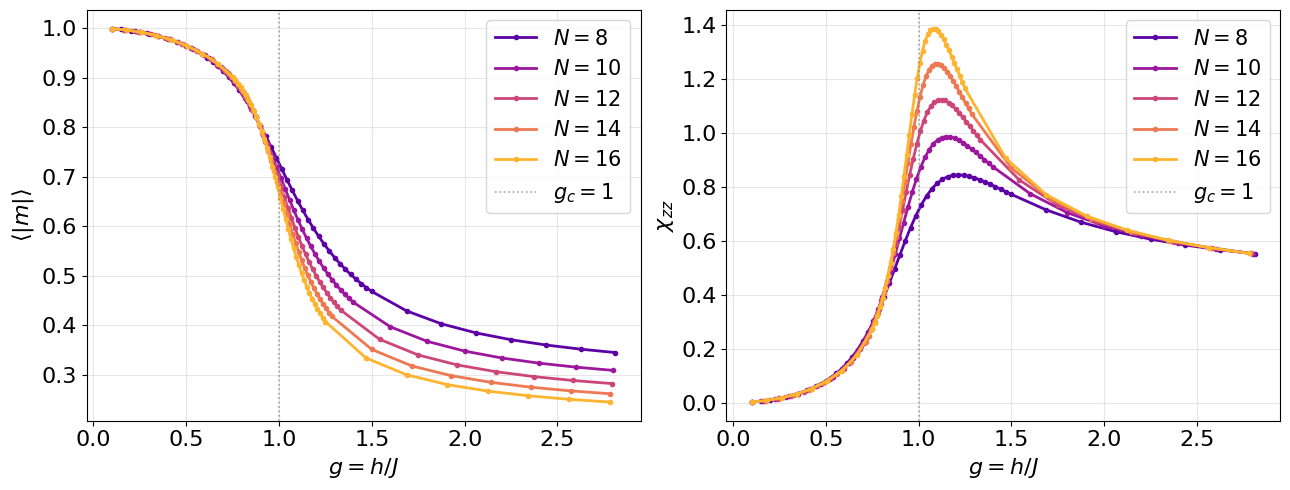

Figura 1 guardada.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for N, col in zip(N_SIZES, colors):
    g   = results[N]["g"]
    lbl = f"$N={N}$"
    axes[0].plot(g, results[N]["m"],   color=col, lw=2, marker="o", ms=3, label=lbl)
    axes[1].plot(g, results[N]["chi"], color=col, lw=2, marker="o", ms=3, label=lbl)

for ax in axes:
    ax.axvline(GC, color="gray", ls=":", lw=1.2, alpha=0.7, label=r"$g_c=1$")
    ax.legend(fontsize=15, loc = "upper right")
    ax.grid(alpha=0.3)
    ax.set_xlabel(r"$g = h/J$", fontsize=16)

axes[0].set_ylabel(r"$\langle|m|\rangle$", fontsize=16)
axes[1].set_ylabel(r"$\chi_{zz}$", fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)
axes[1].tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.savefig("tfim_thermodyn_vs_finite.png", dpi=300)
plt.show()

print("Figura 1 guardada.")

## 3. Figura 2: colapso de escala

In [ ]:
# Colapso de escala finita con exponentes exactos del TFIM (nu=1, beta/nu=1/8, gamma/nu=7/4):
#   m*N^(beta/nu)   vs (g-gc)*N^(1/nu)
#   chi/N^(gamma/nu) vs (g-gc)*N^(1/nu)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    r"TFIM 1D - colapso de escala finita"
    "\n"
    r"($\nu=1,\ \beta/\nu=1/8,\ \gamma/\nu=7/4$, exponentes exactos)",
    fontsize=12, fontweight="bold"
)

for N, col in zip(N_SIZES, colors):
    g   = results[N]["g"]
    m   = results[N]["m"]
    chi = results[N]["chi"]
    x   = (g - GC) * N**(1.0/NU)
    axes[0].plot(x, m   * N**(BETA_C/NU),  color=col, lw=2, marker="o", ms=3, label=f"$N={N}$")
    axes[1].plot(x, chi / N**(GAMMA/NU),   color=col, lw=2, marker="o", ms=3, label=f"$N={N}$")

for ax in axes:
    ax.axvline(0, color="gray", ls=":", lw=1.2, alpha=0.7, label=r"$g_c$")
    ax.set_xlim(-5, 5)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlabel(r"$(g - g_c)\, N^{1/\nu}$", fontsize=12)

axes[0].set_ylabel(r"$\langle|m|\rangle \cdot N^{\beta/\nu}$", fontsize=12)
axes[0].set_title("Colapso de la magnetizacion", fontsize=12)
axes[0].set_ylim(bottom=0)
axes[1].set_ylabel(r"$N\cdot\mathrm{Var}(m)\;/\;N^{\gamma/\nu}$", fontsize=12)
axes[1].set_title("Colapso de la susceptibilidad", fontsize=12)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/tfim_fss_collapse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 2 guardada.")

## 4. Figura 3: extracción de exponentes críticos

In [ ]:
# Extraccion de exponentes desde el pico: chi_max(N)~N^(gamma/nu), m(gc,N)~N^(-beta/nu), g*(N)-gc~N^(-1/nu)
# Nota: para N=8..16 las correcciones de escala finita son notables (sobre todo en chi_max);
# el colapso (Fig. 2) es el analisis mas robusto.

N_arr    = np.array(N_SIZES, dtype=float)
g_peak   = np.zeros(len(N_SIZES))
chi_peak = np.zeros(len(N_SIZES))
m_at_gc  = np.zeros(len(N_SIZES))

for k, N in enumerate(N_SIZES):
    g   = results[N]["g"]
    chi = results[N]["chi"]
    m   = results[N]["m"]

    # Pico de chi por interpolacion parabolica
    i_max = np.argmax(chi)
    if 0 < i_max < len(chi)-1:
        p           = np.polyfit(g[i_max-1:i_max+2], chi[i_max-1:i_max+2], 2)
        g_peak[k]   = -p[1] / (2*p[0])
        chi_peak[k] = np.polyval(p, g_peak[k])
    else:
        g_peak[k]   = g[i_max]
        chi_peak[k] = chi[i_max]

    # m en gc por interpolacion lineal
    i_gc = np.argmin(np.abs(g - GC))
    if i_gc + 1 < len(g) and g[i_gc] < GC:
        t = (GC - g[i_gc]) / (g[i_gc+1] - g[i_gc])
        m_at_gc[k] = m[i_gc] + t*(m[i_gc+1] - m[i_gc])
    else:
        m_at_gc[k] = m[i_gc]

# Ajuste log-log: y = a*N^b
def power_law(logN, log_a, b):
    return log_a + b * logN

logN = np.log(N_arr)
popt_chi, _ = curve_fit(power_law, logN, np.log(chi_peak))
popt_m,   _ = curve_fit(power_law, logN, np.log(m_at_gc))
dg = g_peak - GC
popt_g,   _ = curve_fit(power_law, logN, np.log(dg))

gamma_nu_fit = popt_chi[1]
beta_nu_fit  = -popt_m[1]
nu_fit       = -1.0 / popt_g[1]

print("\nExponentes extraidos (ajuste log-log):")
print(f"  gamma/nu  = {gamma_nu_fit:.3f}  (exacto: {GAMMA/NU:.3f})")
print(f"  beta/nu   = {beta_nu_fit:.3f}  (exacto: {BETA_C/NU:.3f})")
print(f"  nu        = {nu_fit:.3f}  (exacto: {NU:.3f})")
print(f"\n  Las desviaciones reflejan correcciones de escala finita para N=8..16.")
print(f"  El colapso (Fig. 2) es mas robusto que estos ajustes.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "TFIM 1D - extraccion de exponentes criticos\n"
    r"(correcciones de escala finita son significativas para $N\leq16$)",
    fontsize=12, fontweight="bold"
)

N_fit = np.linspace(N_arr.min()*0.85, N_arr.max()*1.15, 100)

ax = axes[0]
for k, (N, col) in enumerate(zip(N_SIZES, colors)):
    ax.loglog(N, chi_peak[k], "o", color=col, ms=9)
ax.loglog(N_fit, np.exp(popt_chi[0]) * N_fit**popt_chi[1], "--", color="k",
          label=fr"ajuste: $\gamma/\nu={gamma_nu_fit:.2f}$" "\n"
                fr"exacto: $\gamma/\nu={GAMMA/NU:.2f}$")
ax.set_xlabel(r"$N$", fontsize=12)
ax.set_ylabel(r"$\chi_{\max}$", fontsize=12)
ax.set_title(r"$\chi_{\max} \sim N^{\gamma/\nu}$", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both")

ax = axes[1]
for k, (N, col) in enumerate(zip(N_SIZES, colors)):
    ax.loglog(N, m_at_gc[k], "o", color=col, ms=9)
ax.loglog(N_fit, np.exp(popt_m[0]) * N_fit**popt_m[1], "--", color="k",
          label=fr"ajuste: $\beta/\nu={beta_nu_fit:.3f}$" "\n"
                fr"exacto: $\beta/\nu={BETA_C/NU:.3f}$")
ax.set_xlabel(r"$N$", fontsize=12)
ax.set_ylabel(r"$\langle|m|\rangle(g_c)$", fontsize=12)
ax.set_title(r"$m(g_c,N) \sim N^{-\beta/\nu}$", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both")

ax = axes[2]
for k, (N, col) in enumerate(zip(N_SIZES, colors)):
    ax.loglog(N, dg[k], "o", color=col, ms=9)
ax.loglog(N_fit, np.exp(popt_g[0]) * N_fit**popt_g[1], "--", color="k",
          label=fr"ajuste: $\nu={nu_fit:.2f}$" "\n"
                fr"exacto: $\nu={NU:.2f}$")
ax.set_xlabel(r"$N$", fontsize=12)
ax.set_ylabel(r"$g^*(N) - g_c$", fontsize=12)
ax.set_title(r"$g^*(N) - g_c \sim N^{-1/\nu}$", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/tfim_fss_exponents.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 3 guardada.")